In [2]:
import pandas as pd
import yfinance as yf
import numpy as np
from datetime import date

stocks = [
    "ADANIENT.NS",  "ADANIPORTS.NS", "APOLLOHOSP.NS", "ASIANPAINT.NS",
    "AXISBANK.NS",  "BAJAJ-AUTO.NS", "BAJAJFINSV.NS", "BAJFINANCE.NS",
    "BEL.NS",       "BHARTIARTL.NS", "BPCL.NS",       "BRITANNIA.NS",
    "CIPLA.NS",     "COALINDIA.NS",  "DIVISLAB.NS",   "DRREDDY.NS",
    "EICHERMOT.NS", "GRASIM.NS",     "HCLTECH.NS",    "HDFCBANK.NS",
    "HDFCLIFE.NS",  "HEROMOTOCO.NS", "HINDALCO.NS",   "HINDUNILVR.NS",
    "ICICIBANK.NS", "INDUSINDBK.NS", "INFY.NS",       "ITC.NS",
    "JIOFIN.NS",    "JSWSTEEL.NS",   "KOTAKBANK.NS",  "LT.NS",
    "M&M.NS",       "MARUTI.NS",     "NESTLEIND.NS",  "NTPC.NS",
    "ONGC.NS",      "POWERGRID.NS",  "RELIANCE.NS",   "SBILIFE.NS",
    "SBIN.NS",      "SHRIRAMFIN.NS", "SUNPHARMA.NS",  "TATACONSUM.NS",
    "TATASTEEL.NS",  "TCS.NS",        "TECHM.NS",
    "TITAN.NS",     "ULTRACEMCO.NS"
]

end = pd.to_datetime(date.today())-pd.offsets.MonthEnd(1)
start = end - pd.DateOffset(years=1)
mom_start = end - pd.DateOffset(years=2)

price = yf.download(tickers=stocks, start=mom_start, end=end)["Close"]

C:\Users\preet\AppData\Local\Temp\ipykernel_25500\2277492980.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(tickers=stocks, start=mom_start, end=end)["Close"]
[*********************100%***********************]  49 of 49 completed


In [3]:
price["ADANIENT.NS"][price.index <= start][-1]

C:\Users\preet\AppData\Local\Temp\ipykernel_25500\3397428422.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  price["ADANIENT.NS"][price.index <= start][-1]


np.float64(2314.652587890625)

In [4]:
mcap = pd.DataFrame({
    stock : price[stock][price.index <= start].iloc[-1] * yf.Ticker(stock).info["sharesOutstanding"]
    for stock in price.columns
},index=["mcap"]).T
mcap["rank"] = mcap["mcap"].rank()

size_stk = {}
for i in range(len(mcap)):
    if mcap.iloc[i,1] <= 10:
        size_stk[mcap.index[i]] = "Long"
    elif mcap.iloc[i,1] > len(mcap) - 10:
        size_stk[mcap.index[i]] ="Short"
    else:
        continue

size_p = pd.DataFrame(size_stk, index=["Positions"]).T
size_p = size_p.sort_values("Positions")
size_p = size_p.reset_index()
size_p.rename(columns = {"index":"Stock"}, inplace = True)

size_p[f"Price as on: {start.date()}"] = size_p["Stock"].map(price.asof(start))
size_p[f"Price as on: {end}"] = size_p["Stock"].map(price.asof(pd.to_datetime(end)))

for i in range(len(size_p)):
    if size_p.loc[i,"Positions"] == "Long":
        size_p.loc[i,"Return"] = size_p.loc[i,f"Price as on: {end}"] / size_p.loc[i,f"Price as on: {start.date()}"] - 1
    elif size_p.loc[i,"Positions"] == "Short":
        size_p.loc[i,"Return"] = 1- size_p.loc[i,f"Price as on: {end}"] / size_p.loc[i,f"Price as on: {start.date()}"]
    else:
        continue

size_short_return = np.average(size_p["Return"][size_p["Positions"]=="Short"])
size_long_return = np.average(size_p["Return"][size_p["Positions"]=="Long"])
size_portfolio_return = np.average(size_p["Return"])



In [5]:
pb = pd.DataFrame({
    stock : price[stock][price.index <= start].iloc[-1] / yf.Ticker(stock).info["bookValue"]
    for stock in price.columns
}, index=["p/b"]).T
pb["rank"] = pb["p/b"].rank()

value_stk = {}
for i in range(len(pb)):
    if pb.iloc[i,1] <= 10:
        value_stk[pb.index[i]] = "Long"
    elif pb.iloc[i,1] > len(pb) - 10:
        value_stk[pb.index[i]] = "Short"
    else:
        continue

value_p = pd.DataFrame(value_stk, index=["Positions"]).T
value_p = value_p.sort_values("Positions")
value_p = value_p.reset_index()
value_p.rename(columns = {"index":"Stock"}, inplace = True)

value_p[f"Price as on: {start.date()}"] = value_p["Stock"].map(price.asof(start))
value_p[f"Price as on: {end}"] = value_p["Stock"].map(price.asof(pd.to_datetime(end)))

for i in range(len(value_p)):
    if value_p.loc[i,"Positions"] == "Long":
        value_p.loc[i,"Return"] = value_p.loc[i,f"Price as on: {end}"] / value_p.loc[i,f"Price as on: {start.date()}"] - 1
    elif value_p.loc[i,"Positions"] == "Short":
        value_p.loc[i,"Return"] = 1- value_p.loc[i,f"Price as on: {end}"] / value_p.loc[i,f"Price as on: {start.date()}"]
    else:
        continue

value_short_return = np.average(value_p["Return"][value_p["Positions"]=="Short"])
value_long_return = np.average(value_p["Return"][value_p["Positions"]=="Long"])
value_portfolio_return = np.average(value_p["Return"])


In [6]:
price["ADANIENT.NS"][price.index >= mom_start][0]

C:\Users\preet\AppData\Local\Temp\ipykernel_25500\1071341588.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  price["ADANIENT.NS"][price.index >= mom_start][0]


np.float64(3249.21826171875)

In [7]:
mom = pd.DataFrame({
    stock: price[stock][price.index >= mom_start].iloc[0] / price[stock][price.index >= start].iloc[0] -1
    for stock in price.columns
}, index = ["mom_score"]).T
mom["rank"] = mom["mom_score"].rank(ascending = False)

mom_stk = {}
for i in range(len(mom)):
    if mom.iloc[i,1] <= 10:
        mom_stk[mom.index[i]] = "Long"
    elif mom.iloc[i,1] > len(pb) - 10:
        mom_stk[mom.index[i]] = "Short"
    else:
        continue

mom_p = pd.DataFrame(mom_stk, index=["Positions"]).T
mom_p = mom_p.sort_values("Positions")
mom_p = mom_p.reset_index()
mom_p.rename(columns = {"index":"Stock"}, inplace = True)

mom_p[f"Price as on: {start.date()}"] = mom_p["Stock"].map(price.asof(start))
mom_p[f"Price as on: {end}"] = mom_p["Stock"].map(price.asof(pd.to_datetime(end)))

for i in range(len(mom_p)):
    if mom_p.loc[i,"Positions"] == "Long":
        mom_p.loc[i,"Return"] = mom_p.loc[i,f"Price as on: {end}"] / mom_p.loc[i,f"Price as on: {start.date()}"] - 1
    elif mom_p.loc[i,"Positions"] == "Short":
        mom_p.loc[i,"Return"] = 1- mom_p.loc[i,f"Price as on: {end}"] / mom_p.loc[i,f"Price as on: {start.date()}"]
    else:
        continue

mom_short_return = np.average(mom_p["Return"][mom_p["Positions"]=="Short"])
mom_long_return = np.average(mom_p["Return"][mom_p["Positions"]=="Long"])
mom_portfolio_return = np.average(mom_p["Return"])


In [8]:
mom_p

,Stock,Positions,Price as on: 2025-03-31,Price as on: 2026-03-31 00:00:00,Return
0,ADANIENT.NS,Long,2314.652588,1758.800049,-0.240145
1,RELIANCE.NS,Long,1270.027588,1343.900024,0.058166
2,NESTLEIND.NS,Long,1114.645020,1174.800049,0.053968
3,JIOFIN.NS,Long,227.155777,224.100006,-0.013452
4,INDUSINDBK.NS,Long,649.849976,752.450012,0.157883
5,HEROMOTOCO.NS,Long,3597.376465,5063.000000,0.407415
6,TITAN.NS,Long,3054.158691,3951.399902,0.293777
7,BAJAJ-AUTO.NS,Long,7684.104492,8781.500000,0.142814
8,ASIANPAINT.NS,Long,2315.638184,2165.199951,-0.064966
9,ADANIPORTS.NS,Long,1177.222534,1312.599976,0.114997


In [9]:
print(size_long_return, size_short_return, size_portfolio_return)
print(value_long_return, value_short_return, value_portfolio_return)
print(mom_long_return, mom_short_return, mom_portfolio_return)

0.08501364776556727 0.08428505662702804 0.08464935219629764
0.11976597056977938 -0.05329428616381486 0.033235842202982244
0.09104553662391285 -0.07905302703323733 0.005996254795337763


In [10]:
def sharpe_ratio(portfolio_return,risk_free,m_returns):
    sharpe = (portfolio_return - risk_free)/np.std(m_returns)
    return sharpe

r_f = .065

In [11]:
monthly_price = price.resample("ME").last()
monthly_returns = monthly_price[start:end].pct_change()

monthly_returns

Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SBILIFE.NS,SBIN.NS,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-30,-0.006261,0.028361,0.054533,0.036336,0.075318,0.019184,-0.027773,-0.034777,0.042413,0.075632,...,0.140808,0.022229,-0.067531,0.056263,0.163589,-0.091805,-0.042275,0.059757,0.103269,0.011421
2025-05-31,0.094990,0.177805,-0.013831,-0.068681,0.006076,0.071856,0.033716,0.069795,0.224451,-0.004452,...,0.026277,0.050670,0.045202,-0.084429,-0.044005,0.149486,0.002809,0.047172,0.051869,-0.037024
2025-06-30,0.040001,0.017068,0.052540,0.045859,0.005871,-0.002175,0.019630,0.020097,0.095944,0.082642,...,0.014402,0.009910,0.105576,-0.001133,-0.006689,0.015313,0.008481,0.071860,0.038031,0.078769
2025-07-31,-0.072039,-0.053165,0.035349,0.023493,-0.108311,-0.043935,-0.052529,-0.059050,-0.091103,-0.039459,...,0.001305,-0.029012,-0.103516,0.021853,-0.023387,-0.011392,-0.119842,-0.116512,-0.090192,0.019320
2025-08-31,-0.076521,-0.043915,0.016236,0.051125,-0.021715,0.077860,-0.017710,-0.003802,-0.033524,-0.013321,...,-0.019123,0.007470,-0.080209,-0.065741,-0.007268,-0.021907,0.015773,0.012093,0.084098,0.031921
2025-09-30,0.116363,0.069089,-0.026413,-0.066942,0.082664,0.005445,0.048550,0.137894,0.093530,-0.005506,...,-0.008253,0.087165,0.061784,-0.000125,0.059977,0.092504,-0.063637,-0.054746,-0.072145,-0.033070
2025-10-31,-0.009937,0.034200,0.036712,0.068426,0.089431,0.024659,0.040819,0.043948,0.054833,0.093750,...,0.092204,0.073987,0.215549,0.060465,0.031612,0.083368,0.062666,0.027861,0.112771,-0.022500
2025-11-30,-0.080935,0.045057,-0.044981,0.146601,0.038043,0.020354,0.002729,-0.005083,-0.033678,0.022925,...,0.005267,0.044824,0.144131,0.083338,0.006352,-0.081383,0.025997,0.065220,0.042971,-0.029045


In [12]:
size_m_ret = pd.DataFrame({
    stock : monthly_returns[stock]
    for stock in size_stk.keys()
},  index=monthly_returns.index, columns=size_stk.keys())

size_m_ret["return"] = monthly_returns[size_p["Stock"][size_p["Positions"]=="Long"]].mean(axis=1) -monthly_returns[size_p["Stock"][size_p["Positions"]=="Short"]].mean(axis=1)
size_m_ret = size_m_ret.dropna(subset=["return"])
size_m_ret["cum_return"] = (1 + size_m_ret["return"]).cumprod() - 1

value_m_ret = pd.DataFrame({
    stock : monthly_returns[stock]
    for stock in value_stk.keys()
},  index=monthly_returns.index, columns=value_stk.keys())

value_m_ret["return"] = monthly_returns[value_p["Stock"][value_p["Positions"]=="Long"]].mean(axis=1) -monthly_returns[value_p["Stock"][value_p["Positions"]=="Short"]].mean(axis=1)
value_m_ret = value_m_ret.dropna(subset=["return"])
value_m_ret["cum_return"] = (1 + value_m_ret["return"]).cumprod() - 1

mom_m_ret = pd.DataFrame({
    stock : monthly_returns[stock]
    for stock in mom_stk.keys()
},  index=monthly_returns.index, columns=mom_stk.keys())

mom_m_ret["return"] = monthly_returns[mom_p["Stock"][mom_p["Positions"]=="Long"]].mean(axis=1) -monthly_returns[mom_p["Stock"][mom_p["Positions"]=="Short"]].mean(axis=1)
mom_m_ret = mom_m_ret.dropna(subset=["return"])
mom_m_ret["cum_return"] = (1 + mom_m_ret["return"]).cumprod() - 1


In [17]:
mom_m_ret

,ADANIENT.NS,ADANIPORTS.NS,ASIANPAINT.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,DIVISLAB.NS,EICHERMOT.NS,HDFCBANK.NS,...,INDUSINDBK.NS,JIOFIN.NS,JSWSTEEL.NS,M&M.NS,NESTLEIND.NS,RELIANCE.NS,SHRIRAMFIN.NS,TITAN.NS,return,cum_return
Date,,,,,,,,,,,,,,,,,,,,,
2025-04-30,-0.006261,0.028361,0.036336,0.019184,-0.034777,0.042413,0.075632,0.053944,0.041008,0.052948,...,0.290144,0.144653,-0.031414,0.098657,0.061069,0.101874,-0.067531,0.103269,0.051747,0.051747
2025-05-31,0.094990,0.177805,-0.068681,0.071856,0.069795,0.224451,-0.004452,0.086249,-0.041944,0.010338,...,-0.025584,0.100722,-0.035250,0.016389,0.003350,0.011317,0.045202,0.051869,0.015960,0.068533
2025-06-30,0.040001,0.017068,0.045859,-0.002175,0.020097,0.095944,0.082642,0.029870,0.060561,0.040423,...,0.067507,0.139892,0.027177,0.069336,0.028837,0.056091,0.105576,0.038031,-0.011727,0.056002
2025-07-31,-0.072039,-0.053165,0.023493,-0.043935,-0.059050,-0.091103,-0.039459,-0.027016,-0.033236,0.010853,...,-0.083935,0.007651,0.030008,0.014336,-0.084432,-0.073571,-0.103516,-0.090192,-0.017579,0.037439
2025-08-31,-0.076521,-0.043915,0.051125,0.077860,-0.003802,-0.033524,-0.013321,-0.070351,0.130499,-0.056981,...,-0.074352,-0.051827,-0.020700,-0.001124,0.028785,-0.019838,-0.080209,0.084098,0.036818,0.075635
2025-09-30,0.116363,0.069089,-0.066942,0.005445,0.137894,0.093530,-0.005506,-0.072087,0.147878,-0.000630,...,-0.005341,-0.059352,0.113092,0.071105,-0.002854,0.005010,0.061784,-0.072145,-0.044653,0.027605
2025-10-31,-0.009937,0.034200,0.068426,0.024659,0.043948,0.054833,0.093750,0.184287,0.000214,0.038170,...,0.080552,0.046385,0.055395,0.017566,0.102958,0.089736,0.215549,0.112771,-0.013890,0.013332
2025-11-30,-0.080935,0.045057,0.146601,0.020354,-0.005083,-0.033678,0.022925,-0.038736,0.006636,0.020561,...,0.080209,-0.001956,-0.037894,0.077455,-0.008257,0.054561,0.144131,0.042971,0.022368,0.035998
2025-12-31,-0.017762,-0.031050,-0.036495,0.029702,-0.048867,-0.029508,0.001903,-0.013046,0.036719,-0.016276,...,0.006581,-0.036741,0.003878,-0.012802,0.021331,0.001850,0.169729,0.036799,-0.014981,0.020478


In [13]:

size_sharpe = sharpe_ratio(risk_free=r_f, portfolio_return=size_portfolio_return,m_returns=size_m_ret["return"])
value_sharpe = sharpe_ratio(risk_free=r_f, portfolio_return=size_portfolio_return,m_returns=value_m_ret["return"])
mom_sharpe = sharpe_ratio(risk_free=r_f, portfolio_return=size_portfolio_return,m_returns=mom_m_ret["return"])

sharpe_ratios = pd.DataFrame({
    "size" : size_sharpe,
    "value" : value_sharpe,
    "mom" : mom_sharpe
}, index=["Sharpe Ratio"]).T

sharpe_ratios

,Sharpe Ratio
size,0.776243
value,0.704985
mom,0.720423


In [121]:
import matplotlib.pyplot as plt
from matplotlib import ticker as mtk

In [122]:
mom_y = mom_m_ret["cum_return"]
value_y = value_m_ret["cum_return"]
size_y = size_m_ret["cum_return"]

maxmom = max(mom_m_ret["cum_return"])
maxval = max(value_m_ret["cum_return"])
maxsize = max(size_m_ret["cum_return"])

minmom = min(mom_m_ret["cum_return"])
minval = min(value_m_ret["cum_return"])
minsize = min(size_m_ret["cum_return"])

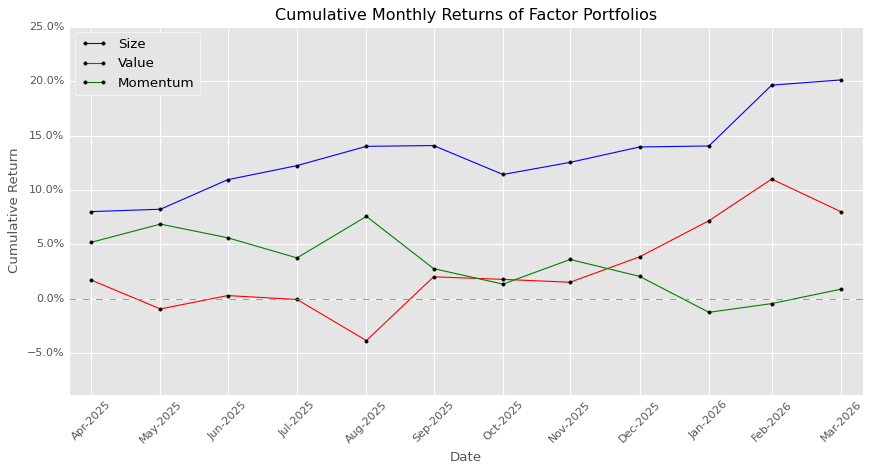

In [123]:
fig, ax = plt.subplots(figsize=(11,6))

fmt = dict(marker="o", markersize=3, mfc="k", lw=1)

ax.plot(size_m_ret.index, size_y, label="Size", color="blue", **fmt)
ax.plot(value_m_ret.index, value_y, label="Value", color="red", **fmt)
ax.plot(mom_m_ret.index, mom_y, label="Momentum", color="green", **fmt)

ax.set_xticks(size_m_ret.index)
ax.set_xticklabels([d.strftime("%b-%Y") for d in size_m_ret.index], rotation = 45)
ax.set_xlim(mom_m_ret.index[0] - pd.DateOffset(days=10),mom_m_ret.index[-1] + pd.DateOffset(days=10))

ax.yaxis.set_major_formatter(mtk.PercentFormatter(xmax=1.0))
ax.set_ylim(min(minmom,minsize,minval)-0.05,max(maxmom,maxsize,maxval)+0.05)

ax.axhline(0, lw=.7, ls="--", color="grey")
ax.legend(loc="best")

ax.set_title("Cumulative Monthly Returns of Factor Portfolios")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")

plt.tight_layout()
plt.show()